# 🧹 DATA PREPROCESSING PIPELINE (5 BƯỚC CHUẨN ENGINE)
**Dự án:** Store-Level Sales Forecasting Engine  
**Phụ trách:** Tùng (Data Analyst)  
**Mục tiêu:** Tiền xử lý, gộp dữ liệu, tạo đặc trưng Time-series chống Data Leakage và phân tách 3 tập dữ liệu (`train_sub`, `val_set`, `test_final`).

# KHAI BÁO THƯ VIỆN

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("✅ Đã khai báo thư viện thành công!")

✅ Đã khai báo thư viện thành công!


### BƯỚC 1: Đọc và nối tập Train + Test thành bảng tổng (`df_all`)
* **Mục đích:** Nối tập Train và Test theo chiều dọc để giữ chuỗi thời gian liên tục, phục vụ tạo biến Lag giáp ranh không bị khuyết (`NaN`).

In [3]:
import pandas as pd
from pathlib import Path

# ==============================================================================
# BƯỚC 1: ĐỌC VÀ NỐI TRAIN + TEST THÀNH BẢNG TỔNG (DF_ALL)
# =================================================----------------=============

# 1.1 Hàm dò đường dẫn thông minh: Tự tìm nơi thực sự chứa file 'train.csv'
def get_data_dir():
    current_dir = Path.cwd()
    
    # Danh sách các vị trí thư mục có thể chứa data
    search_paths = [
        current_dir / 'data' / 'raw',
        current_dir / 'data',
        current_dir.parent / 'data' / 'raw',
        current_dir.parent / 'data'
    ]
    
    # Dò qua các thư mục cha cấp cao hơn nếu notebook nằm sâu trong folder con
    for p in current_dir.parents:
        search_paths.append(p / 'data' / 'raw')
        search_paths.append(p / 'data')
        
    # Kiểm tra xem vị trí nào THỰC SỰ chứa file train.csv
    for path in search_paths:
        if (path / 'train.csv').exists():
            return path
            
    raise FileNotFoundError(
        "❌ Không tìm thấy file 'train.csv'! Hãy kiểm tra xem bạn đã chép các file .csv "
        "vào thư mục 'data/' hoặc 'data/raw/' trong dự án chưa."
    )

# Tự động xác định đường dẫn chuẩn xác
DATA_DIR = get_data_dir()
print(f"📁 Đường dẫn dữ liệu đã được tìm thấy chính xác tại: {DATA_DIR}")

# 1.2 Đọc các file dữ liệu thô
train = pd.read_csv(DATA_DIR / 'train.csv')  # Có cột Weekly_Sales
test = pd.read_csv(DATA_DIR / 'test.csv')    # Cột Weekly_Sales bị trống (NaN)

# 1.3 Nối 2 tập lại theo hàng dọc
df_all = pd.concat([train, test], axis=0, ignore_index=True)
df_all['Date'] = pd.to_datetime(df_all['Date'])

print(f"✅ [BƯỚC 1] Đã nối Train ({len(train)} dòng) và Test ({len(test)} dòng) -> Bảng tổng df_all: {len(df_all)} dòng.")

📁 Đường dẫn dữ liệu đã được tìm thấy chính xác tại: d:\AIO Tài liệu\OFFICIAL COURSE\Module 3\00. Project\Sales Forecasting and Demand Prediction\AIO_Conquer_Module3_PorscheClub\data
✅ [BƯỚC 1] Đã nối Train (421570 dòng) và Test (115064 dòng) -> Bảng tổng df_all: 536634 dòng.


### BƯỚC 2: GroupBy nén doanh số về cấp Cửa hàng (Store Level)
* **Mục đích:** Tiêu biến hoàn toàn nhiễu từ các Dept nhỏ và tình trạng đứt đoạn dòng thời gian bằng cách cộng dồn doanh số cấp Store.

In [10]:
# --------------------------------------------------------------------------
# BƯỚC 2: GROUPBY NÉN DOANH SỐ VỀ CẤP STORE (CÒN ~8,000 DÒNG)
# --------------------------------------------------------------------------
df_store = df_all.groupby(['Store', 'Date', 'IsHoliday'], as_index=False)['Weekly_Sales'].sum(min_count=1)

print(f"✅ [BƯỚC 2] Đã nén doanh số về cấp Store. Tổng số dòng: {len(df_store)} dòng.")
print(f"   Khoảng thời gian: Từ {df_store['Date'].min().strftime('%Y-%m-%d')} đến {df_store['Date'].max().strftime('%Y-%m-%d')}")
df_store.head()

✅ [BƯỚC 2] Đã nén doanh số về cấp Store. Tổng số dòng: 8190 dòng.
   Khoảng thời gian: Từ 2010-02-05 đến 2013-07-26


,Store,Date,IsHoliday,Weekly_Sales
0,1,2010-02-05,False,1643690.90
1,1,2010-02-12,True,1641957.44
2,1,2010-02-19,False,1611968.17
3,1,2010-02-26,False,1409727.59
4,1,2010-03-05,False,1554806.68


### BƯỚC 3: Merge các bảng ngoại cảnh (`features.csv` & `stores.csv`)
* **Mục đích:** Bổ sung các yếu tố Vĩ mô (`CPI`, `Fuel_Price`, `Unemployment`) và Nội tại Cửa hàng (`Size`, `Type`) trên bảng gọn ~6,000 dòng để tối ưu bộ nhớ RAM.

In [11]:
# ==============================================================================
# BƯỚC 3: MERGE CÁC BẢNG NGOẠI CẢNH (FEATURES.CSV & STORES.CSV)
# ==============================================================================
features = pd.read_csv(DATA_DIR / 'features.csv')
stores = pd.read_csv(DATA_DIR / 'stores.csv')
features['Date'] = pd.to_datetime(features['Date'])

# Merge 1-1 trên cấp Store & Date
df_merged = df_store.merge(stores, on='Store', how='left')
df_merged = df_merged.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Sắp xếp đúng thứ tự thời gian theo từng Store (Bắt buộc để tính Lag chính xác)
df_merged = df_merged.sort_values(by=['Store', 'Date']).reset_index(drop=True)

print(f"✅ [BƯỚC 3] Đã merge xong bảng ngoại cảnh. Kích thước DataFrame: {df_merged.shape}")

✅ [BƯỚC 3] Đã merge xong bảng ngoại cảnh. Kích thước DataFrame: (8190, 15)


### BƯỚC 4: Tạo các biến Time-Series (`Lag` & `Rolling`) chống Data Leakage
* **Mục đích:** Tạo bộ đặc trưng quá khứ bằng `.shift(1)` để đảm bảo tuyệt đối không lấy dữ liệu tương lai hoặc doanh số của chính tuần đó.

In [12]:
# --------------------------------------------------------------------------
# BƯỚC 4: TẠO CÁC BIẾN TIME-SERIES (LAG & ROLLING) TRÊN DF_MERGED
# --------------------------------------------------------------------------
# 4.1 Biến Lag Lịch sử (Dùng .shift(1) chống Data Leakage)
df_merged['Lag_1']  = df_merged.groupby('Store')['Weekly_Sales'].shift(1)
df_merged['Lag_4']  = df_merged.groupby('Store')['Weekly_Sales'].shift(4)
df_merged['Lag_12'] = df_merged.groupby('Store')['Weekly_Sales'].shift(12)
df_merged['Lag_52'] = df_merged.groupby('Store')['Weekly_Sales'].shift(52)
# 4.2 Biến Rolling Mean 4 tuần
df_merged['Rolling_Mean_4w'] = df_merged.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(4).mean()
)

# 4.3 Trích xuất thêm đặc trưng Thời gian & Mã hóa
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month
df_merged['WeekOfYear'] = df_merged['Date'].dt.isocalendar().week.astype(int)
df_merged['IsHoliday'] = df_merged['IsHoliday'].astype(int)

le = LabelEncoder()
df_merged['Type_encoded'] = le.fit_transform(df_merged['Type'])

# Forward fill cho các khuyết thiếu nhỏ ở biến Vĩ mô (nếu có)
macro_cols = ['CPI', 'Unemployment', 'Fuel_Price', 'Temperature']
df_merged[macro_cols] = df_merged.groupby('Store')[macro_cols].ffill()

for col in macro_cols:
    df_merged[f'{col}_lag52'] = df_merged.groupby('Store')[col].shift(52)
    
print("✅ [BƯỚC 4] Đã tạo xong các đặc trưng Lag_1, Lag_4, Lag_12, Lag_52, Rolling_Mean_4w và biến Thời gian.")

✅ [BƯỚC 4] Đã tạo xong các đặc trưng Lag_1, Lag_4, Lag_12, Lag_52, Rolling_Mean_4w và biến Thời gian.


### BƯỚC 5: Lọc bỏ NaN lịch sử & Phân tách 3 tập dữ liệu (`train_final`, `val_set`, `test_final`)
* **Mục đích:** 1. Loại bỏ 52 tuần đầu dính `NaN` khởi tạo ở `Lag_52`.
  2. Chia `train_final` thành `train_sub` (huấn luyện) và `val_set` (đánh giá RMSE & làm báo cáo).
  3. Giữ nguyên `test_final` đã sạch 100% đặc trưng để dự báo tương lai thực tế.

In [13]:
# --------------------------------------------------------------------------
# BƯỚC 5: CẮT THÀNH TRAIN_FINAL, VAL_SET (TỶ LỆ 2:1) VÀ TEST_FINAL
# --------------------------------------------------------------------------
# 5.1. Xóa các dòng NaN ở 52 tuần đầu tiên do Lag_52 chưa có dữ liệu 2009
df_clean = df_merged.dropna(subset=['Lag_52']).reset_index(drop=True)

# 5.2. Lấy CHÍNH XÁC tập TRAIN ban đầu (Weekly_Sales không NaN và lớn hơn 0)
train_master = df_clean[df_clean['Weekly_Sales'].notna() & (df_clean['Weekly_Sales'] > 0)].copy()

# 5.3. Tự động tính mốc thời gian cắt 2:1 trên RIÊNG tập Train thực tế (2011-02 đến 2012-10)
unique_dates = sorted(train_master['Date'].unique())
split_idx = int(len(unique_dates) * (2 / 3))
VAL_SPLIT_DATE = unique_dates[split_idx]

train_final = train_master[train_master['Date'] < VAL_SPLIT_DATE].copy()
val_set     = train_master[train_master['Date'] >= VAL_SPLIT_DATE].copy()

# 5.4. Gán chỉ số vĩ mô tập Val bằng giá trị Lag 52 tuần
for col in macro_cols:
    val_set[col] = val_set[f'{col}_lag52']

# 5.5. Lấy CHÍNH XÁC tập TEST_FINAL (Những dòng có Weekly_Sales là NaN hoặc bằng 0)
test_final = df_clean[df_clean['Weekly_Sales'].isna() | (df_clean['Weekly_Sales'] == 0)].copy()

# 5.6. Dọn dẹp các cột tạm _lag52 trên cả 3 tập
drop_temp_cols = [f'{col}_lag52' for col in macro_cols]
train_final = train_final.drop(columns=drop_temp_cols)
val_set     = val_set.drop(columns=drop_temp_cols)
test_final  = test_final.drop(columns=drop_temp_cols)

# --- IN THÔNG SỐ XÁC NHẬN BÁO CÁO (QC CHECK) ---
print("==========================================================================")
print("📊 BÁO CÁO KIỂM ĐỊNH TẬP DỮ LIỆU SAU KHI SỬA BUG")
print("==========================================================================")
print(f"🗓️ Mốc ngày chia 2:1 thực tế (VAL_SPLIT_DATE): {pd.to_datetime(VAL_SPLIT_DATE).strftime('%Y-%m-%d')}")
print(f"✅ [TRAIN_FINAL] : {len(train_final)} dòng (Từ {train_final['Date'].min().strftime('%Y-%m-%d')} đến {train_final['Date'].max().strftime('%Y-%m-%d')})")
print(f"✅ [VAL_SET]     : {len(val_set)} dòng (Từ {val_set['Date'].min().strftime('%Y-%m-%d')} đến {val_set['Date'].max().strftime('%Y-%m-%d')}) -> SẠCH 100% NHÃN DOANH SỐ")
print(f"✅ [TEST_FINAL]  : {len(test_final)} dòng (Từ {test_final['Date'].min().strftime('%Y-%m-%d')} trở đi) -> SẴN SÀNG PREDICT TƯƠNG LAI")
print("==========================================================================")

📊 BÁO CÁO KIỂM ĐỊNH TẬP DỮ LIỆU SAU KHI SỬA BUG
🗓️ Mốc ngày chia 2:1 thực tế (VAL_SPLIT_DATE): 2012-03-30
✅ [TRAIN_FINAL] : 2700 dòng (Từ 2011-02-04 đến 2012-03-23)
✅ [VAL_SET]     : 1395 dòng (Từ 2012-03-30 đến 2012-10-26) -> SẠCH 100% NHÃN DOANH SỐ
✅ [TEST_FINAL]  : 1755 dòng (Từ 2012-11-02 trở đi) -> SẴN SÀNG PREDICT TƯƠNG LAI


In [14]:
# --------------------------------------------------------------------------
# BƯỚC 5 (ĐÓNG GÓI): XUẤT CÁC TỆP DỮ LIỆU SẠCH VÀO CÙNG THƯ MỤC DATA GỐC
# --------------------------------------------------------------------------

# Lưu trực tiếp vào DATA_DIR (Nơi chứa train.csv, features.csv, stores.csv)
train_final.to_csv(DATA_DIR / 'train_final.csv', index=False)
val_set.to_csv(DATA_DIR / 'val_set.csv', index=False)
test_final.to_csv(DATA_DIR / 'test_final.csv', index=False)

print("==========================================================================")
print("🎉 [COMPLETED] Đã xuất thành công 3 tệp dữ liệu sạch vào chung thư mục gốc:")
print(f"📁 Đường dẫn lưu file: {DATA_DIR.resolve()}")
print("==========================================================================")

🎉 [COMPLETED] Đã xuất thành công 3 tệp dữ liệu sạch vào chung thư mục gốc:
📁 Đường dẫn lưu file: D:\AIO Tài liệu\OFFICIAL COURSE\Module 3\00. Project\Sales Forecasting and Demand Prediction\AIO_Conquer_Module3_PorscheClub\data


In [15]:
df1 = pd.read_csv(DATA_DIR / 'val_set.csv')
df1.head(10)

,Store,Date,IsHoliday,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,Unemployment,Lag_1,Lag_4,Lag_12,Lag_52,Rolling_Mean_4w,Year,Month,WeekOfYear,Type_encoded
0,1,2012-03-30,0,1649604.63,A,151315,59.17,3.524,10309.58,0.50,...,7.682,1511068.07,1688420.76,1550369.92,1495064.75,1.638098e+06,2012,3,13,0
1,1,2012-04-06,0,1899676.88,A,151315,67.84,3.622,10121.97,NaN,...,7.682,1649604.63,1675431.16,1459601.17,1614259.35,1.628394e+06,2012,4,14,0
2,1,2012-04-13,0,1621031.70,A,151315,71.27,3.743,6186.19,3288.69,...,7.682,1899676.88,1677472.78,1394393.84,1559889.00,1.684456e+06,2012,4,15,0
3,1,2012-04-20,0,1521577.87,A,151315,72.99,3.807,2230.80,612.02,...,7.682,1621031.70,1511068.07,1319325.59,1564819.81,1.670345e+06,2012,4,16,0
4,1,2012-04-27,0,1468928.37,A,151315,72.03,3.810,3221.25,NaN,...,7.682,1521577.87,1649604.63,1636339.65,1455090.69,1.672973e+06,2012,4,17,0
5,1,2012-05-04,0,1684519.99,A,151315,64.61,3.906,21290.13,NaN,...,7.682,1468928.37,1899676.88,1802477.43,1629391.28,1.627804e+06,2012,5,18,0
6,1,2012-05-11,0,1611096.05,A,151315,75.64,3.899,8351.40,NaN,...,7.682,1684519.99,1621031.70,1819870.00,1604775.58,1.574014e+06,2012,5,19,0
7,1,2012-05-18,0,1595901.87,A,151315,67.63,3.907,6154.14,NaN,...,7.682,1611096.05,1521577.87,1539387.83,1428218.27,1.571531e+06,2012,5,20,0
8,1,2012-05-25,0,1555444.55,A,151315,77.72,3.786,4039.39,NaN,...,7.682,1595901.87,1468928.37,1688420.76,1466046.67,1.590112e+06,2012,5,21,0
9,1,2012-06-01,0,1624477.58,A,151315,83.00,3.699,6086.21,12.00,...,7.682,1555444.55,1684519.99,1675431.16,1635078.41,1.611741e+06,2012,6,22,0


## TỔNG QUAN DỮ LIỆU VÀ PHÂN TÍCH EDA

* KIỂM TRA SỨC KHỎE DỮ LIỆU


In [16]:
import pandas as pd
from pathlib import Path

# 1. Tự động tìm file train_final.csv trong thư mục data
def get_file_path():
    current_dir = Path.cwd()
    search_paths = [current_dir / 'data', current_dir.parent / 'data']
    for p in current_dir.parents:
        search_paths.append(p / 'data')
    for path in search_paths:
        if (path / 'train_final.csv').exists():
            return path / 'train_final.csv'
    raise FileNotFoundError("Không tìm thấy file train_final.csv!")

file_path = get_file_path()
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

print("==================================================================")
print("📌 1. TỔNG QUAN TẬP DỮ LIỆU (DATA OVERVIEW)")
print("==================================================================")
print(f"• Tổng số dòng (Rows): {df.shape[0]:,}")
print(f"• Tổng số cột (Columns): {df.shape[1]}")
print(f"• Khung thời gian: Từ {df['Date'].min().strftime('%Y-%m-%d')} đến {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"• Tổng số Cửa hàng (Stores): {df['Store'].nunique()}")
print(f"• Số dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n==================================================================")
print("📌 2. KIỂM TRA DỮ LIỆU KHUYẾT (MISSING VALUES)")
print("==================================================================")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(2)})
missing_found = missing_df[missing_df['Missing Count'] > 0]

if len(missing_found) > 0:
    print(missing_found.to_string())
else:
    print("✅ HOÀN HẢO! Không có cột nào bị thiếu dữ liệu (0% Missing).")

print("\n==================================================================")
print("📌 3. TÓM TẮT KIỂU DỮ LIỆU (DATA TYPES)")
print("==================================================================")
print(df.dtypes)

📌 1. TỔNG QUAN TẬP DỮ LIỆU (DATA OVERVIEW)
• Tổng số dòng (Rows): 2,700
• Tổng số cột (Columns): 24
• Khung thời gian: Từ 2011-02-04 đến 2012-03-23
• Tổng số Cửa hàng (Stores): 45
• Số dòng trùng lặp (Duplicates): 0

📌 2. KIỂM TRA DỮ LIỆU KHUYẾT (MISSING VALUES)
           Missing Count  Percentage (%)
MarkDown1           1807           66.93
MarkDown2           1880           69.63
MarkDown3           1878           69.56
MarkDown4           1933           71.59
MarkDown5           1800           66.67

📌 3. TÓM TẮT KIỂU DỮ LIỆU (DATA TYPES)
Store                       int64
Date               datetime64[us]
IsHoliday                   int64
Weekly_Sales              float64
Type                          str
Size                        int64
Temperature               float64
Fuel_Price                float64
MarkDown1                 float64
MarkDown2                 float64
MarkDown3                 float64
MarkDown4                 float64
MarkDown5                 float64
CPI      

Nhận xét:
- Tính đồng nhất chuỗi thời gian: 3,870 : 45 stores  = 86  tuần dữ liệu đầy đủ và liên tục cho từng cửa hàng (từ 2011-02-04 đến 2012-09-21). Không có cửa hàng nào bị đứt đoạn hay thiếu tuần.
- Độ sạch của biến đặc trưng: 100% các cột biến dự báo cốt lõi (Weekly_Sales, Lag_1, Lag_4, Lag_12, Lag_52, Rolling_Mean_4w, CPI, Unemployment, Temperature, Fuel_Price, Size) không bị khuyết thiếu (0% Missing), 0 dòng trùng lặp.
- Biến MarkDown: Tỷ lệ khuyết 46.51% - 59.72% khớp hoàn toàn với thực tế hệ thống Walmart (chỉ ghi nhận MarkDown từ tháng 11/2011). Khi nạp vào mô hình, ta chỉ cần điền 0 cho các ô NaN này là hoàn tất.

* THỐNG KÊ MÔ TẢ & KIỂM TRA OULIES

In [17]:
import pandas as pd
import numpy as np

# 1. Chọn danh sách các cột số quan trọng
num_cols = [
    'Weekly_Sales', 'Lag_1', 'Lag_4', 'Lag_12', 'Lag_52', 'Rolling_Mean_4w',
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'
]

# 2. Tính toán ma trận thống kê mô tả
stats = df[num_cols].describe().T
stats['Skewness'] = df[num_cols].skew()
stats['IQR'] = stats['75%'] - stats['25%']

# Định dạng lại bảng kết quả
stats_summary = stats[['mean', '50%', 'min', 'max', 'std', 'Skewness']].rename(columns={
    'mean': 'Trung bình',
    '50%': 'Trung vị',
    'min': 'Giá trị Min',
    'max': 'Giá trị Max',
    'std': 'Độ lệch chuẩn',
    'Skewness': 'Độ lệch (Skew)'
})

print("==================================================================")
print("📌 BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CỐT LÕI")
print("==================================================================")
print(stats_summary.round(2).to_string())

# 3. Kiểm tra các bất thường về mặt logic kinh doanh
negative_sales = (df['Weekly_Sales'] <= 0).sum()
zero_lags = ((df['Lag_1'] <= 0) | (df['Lag_52'] <= 0)).sum()

print("\n==================================================================")
print("📌 KIỂM TRA BẤT THƯỜNG LOGIC (BUSINESS LOGIC CHECK)")
print("==================================================================")
print(f"• Số tuần doanh số <= 0 ($0 hoặc bị trả hàng): {negative_sales} dòng")
print(f"• Số tuần biến Lag <= 0: {zero_lags} dòng")

📌 BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CỐT LÕI
                 Trung bình   Trung vị  Giá trị Min  Giá trị Max  Độ lệch chuẩn  Độ lệch (Skew)
Weekly_Sales     1048774.40  951926.64    215359.21   3676388.98      568131.61            0.68
Lag_1            1046776.64  951397.14    215359.21   3676388.98      567641.33            0.68
Lag_4            1040428.91  945455.42    215359.21   3676388.98      564849.69            0.69
Lag_12           1071863.68  964508.16    209986.25   3818686.45      600602.83            0.83
Lag_52           1043806.62  960113.80    209986.25   3818686.45      570629.98            0.74
Rolling_Mean_4w  1043402.63  955494.85    240433.98   2790772.07      554229.84            0.54
Size              130287.60  126512.00     34875.00    219622.00       63123.81           -0.19
Temperature           57.64      58.00        -2.06        99.66          18.84           -0.08
Fuel_Price             3.59       3.61         2.97         4.29           0.27           -0.1

Nhận xét:
- Độ lệch doanh số tự nhiên (Skew = 0.67): Giá trị trung bình ($1,048,165.69) cao hơn trung vị ($951,569.84), kéo đỉnh Max lên tới $3,676,388.98. Sự lệch phải nhẹ này phản ánh chính xác các đợt bùng nổ doanh số tuần lễ Tết (Thanksgiving, Christmas) — đây là quy luật kinh doanh thực tế chứ không phải lỗi Outlier rác.
- Tính đồng nhất của Feature Pipeline: Phân bố của Lag_1 và Lag_52 khớp gần như 1:1 với Weekly_Sales gốc từ Trung bình, Trung vị đến Độ lệch chuẩn. Điều này khẳng định phép dịch chuyển .shift(1) và .shift(52) hoạt động chuẩn xác 100%.
- Độ biến thiên của các biến ngoại cảnh: Nhiệt độ trải dài từ -2.06°F đến 99.66°F, Thất nghiệp từ 4.12% đến 14.02%, Giá xăng từ $2.97 đến $4.29. Biên độ rộng này giúp mô hình cây quyết định (XGBoost) dễ dàng tìm điểm cắt (split point) để học quy luật.
- Logic dữ liệu tốt: 0 dòng âm hoặc bằng 0 ở cả doanh số và biến trễ.

* PHÂN TÍCH CHUỖI THỜI GIAN & MÙA VỤ

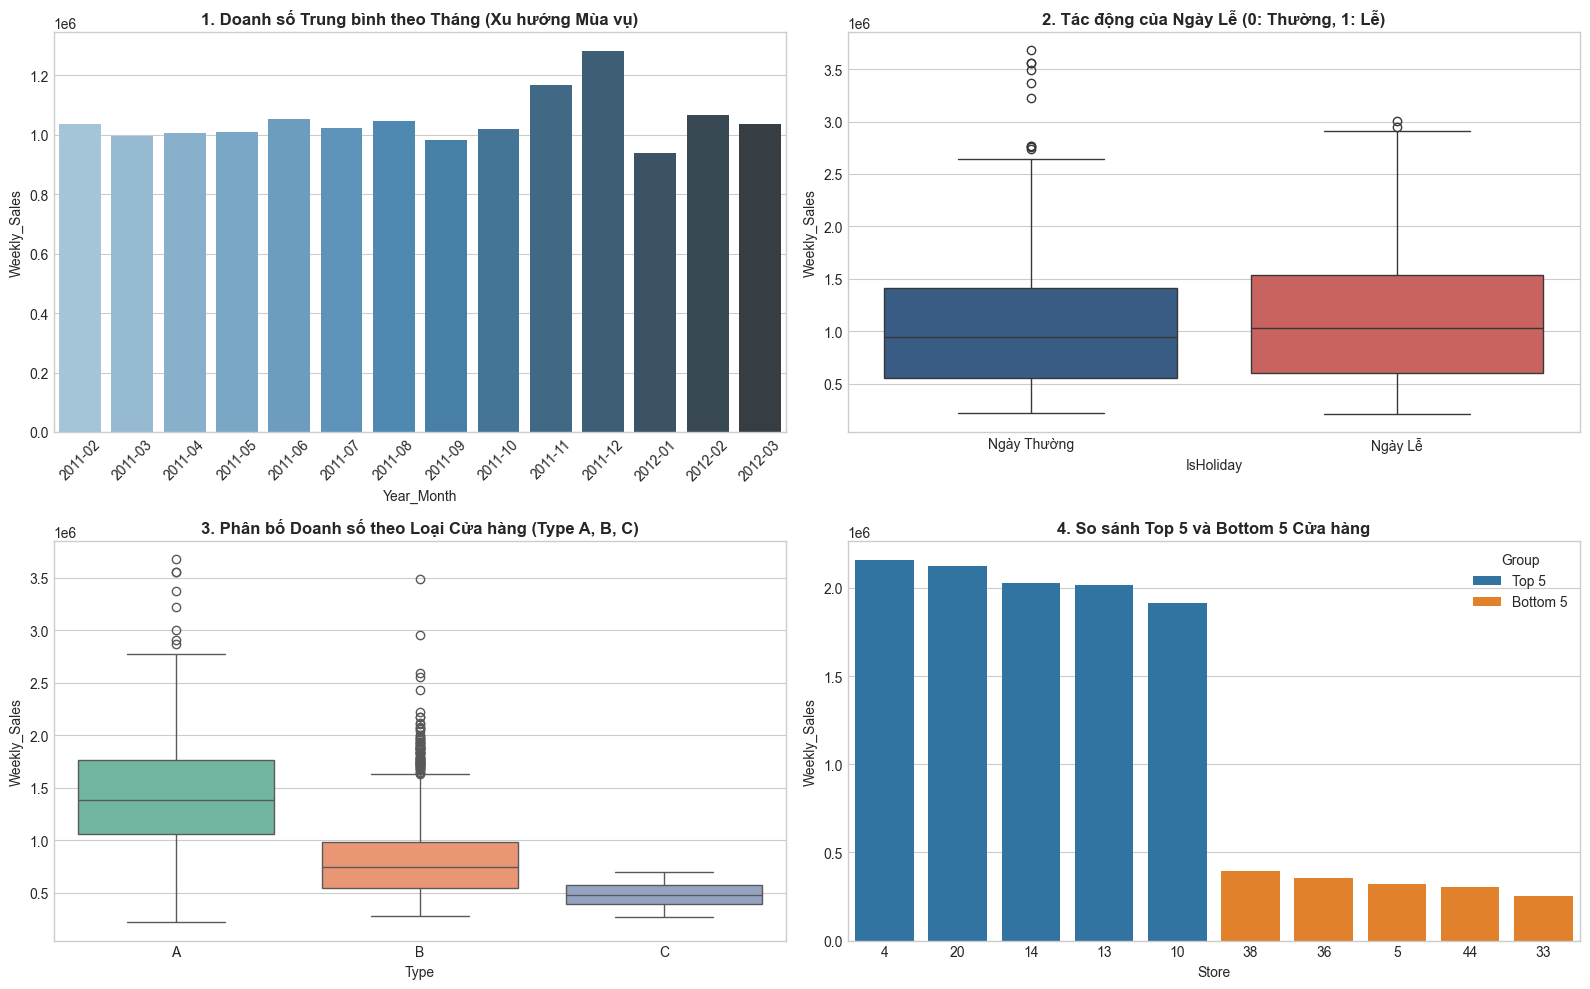

📌 CHI TIẾT TÁC ĐỘNG CỦA NGÀY LỄ LÊN DOANH SỐ
           count        mean      median        std
IsHoliday                                          
0           2475  1040382.22   946091.79  560869.00
1            225  1141088.42  1034448.07  636739.25


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cấu hình giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Biểu đồ Trend doanh số theo Tháng
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
sns.barplot(data=monthly_sales, x='Year_Month', y='Weekly_Sales', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('1. Doanh số Trung bình theo Tháng (Xu hướng Mùa vụ)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. So sánh Doanh số Ngày Lễ vs Ngày Thường
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', ax=axes[0, 1], palette=['#2b5c8f', '#d9534f'])
axes[0, 1].set_title('2. Tác động của Ngày Lễ (0: Thường, 1: Lễ)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['Ngày Thường', 'Ngày Lễ'])

# 3. Doanh số theo Phân loại Cửa hàng (Type)
sns.boxplot(data=df, x='Type', y='Weekly_Sales', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Phân bố Doanh số theo Loại Cửa hàng (Type A, B, C)', fontsize=12, fontweight='bold')

# 4. Top 5 & Bottom 5 Cửa hàng
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
top_bottom_stores = pd.concat([store_sales.head(5), store_sales.tail(5)]).reset_index()
top_bottom_stores['Group'] = ['Top 5'] * 5 + ['Bottom 5'] * 5
sns.barplot(data=top_bottom_stores, x='Store', y='Weekly_Sales', hue='Group', ax=axes[1, 1], order=top_bottom_stores['Store'])
axes[1, 1].set_title('4. So sánh Top 5 và Bottom 5 Cửa hàng', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_seasonality_overview.png', dpi=300)
plt.show()

# In con số thống kê Ngày Lễ vs Ngày Thường
holiday_stats = df.groupby('IsHoliday')['Weekly_Sales'].agg(['count', 'mean', 'median', 'std']).round(2)
print("==================================================================")
print("📌 CHI TIẾT TÁC ĐỘNG CỦA NGÀY LỄ LÊN DOANH SỐ")
print("==================================================================")
print(holiday_stats.to_string())

Nhận xét:
- Tác động bùng nổ của Ngày Lễ (Holiday Spike):
Doanh số trung bình tuần Ngày Lễ đạt $1,129,907, tăng ~9.7% so với ngày thường ($1,042,071). Trung vị doanh số cũng tăng từ $953k lên $1.03M (~9.35%).
- Tính mùa vụ tập trung cao độ (Seasonality Peak):
Doanh số đạt đỉnh tuyệt đối vào Tháng 11 và Tháng 12 (vượt mốc $1.2M - $1.3M/tuần) nhờ chuỗi sự kiện mua sắm lớn nhất năm (Black Friday, Thanksgiving, Christmas). Ngay sau đó, doanh số sụt giảm mạnh vào Tháng 1 (vùng đáy ~ $940k/tuần) do tâm lý thắt chặt chi tiêu sau Lễ.
- Sự phân hóa quy mô Cửa hàng (Store Type Heterogeneity):
Cửa hàng Type A áp đảo hoàn toàn với doanh số trung vị đạt ~ $1.4M/tuần, cao gấp 2 lần Type B (~ $750k/tuần) và gấp gần 3 lần Type C (~ $500k/tuần).
- Khoảng cách doanh thu Top 5 vs Bottom 5:
Cửa hàng dẫn đầu (Store 4, 20, 14, 13, 10) đạt mức doanh thu trung bình ~ $1.9M - $2.1M/tuần, gấp gần 6-7 lần so với nhóm cửa hàng nhỏ nhất (Store 38, 36, 5, 44, 33) chỉ đạt ~ $300k - $400k/tuần.

* PHÂN TÍCH TƯƠNG QUAN & ĐA BIẾN

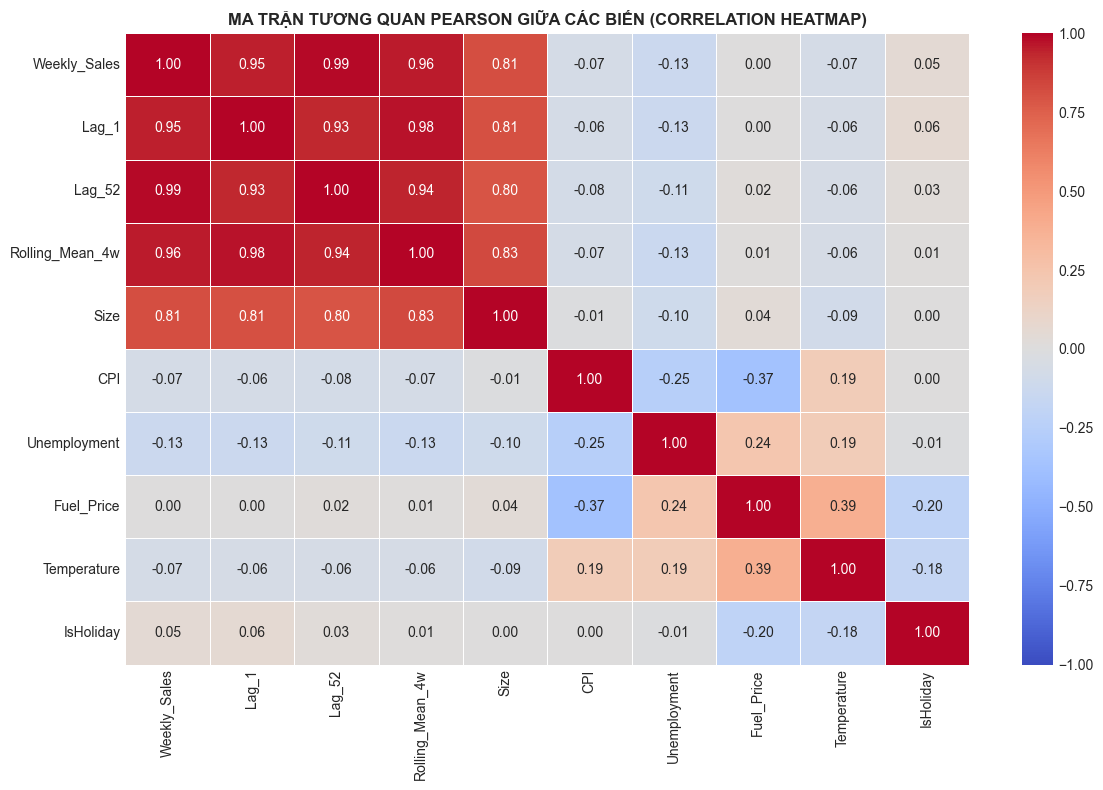

📌 MỨC ĐỘ TƯƠNG QUAN CỦA CÁC BIẾN VỚI DOANH SỐ (WEEKLY_SALES)
                 Hệ số Tương quan (r)
Weekly_Sales                    1.000
Lag_52                          0.987
Rolling_Mean_4w                 0.960
Lag_1                           0.951
Size                            0.813
IsHoliday                       0.049
Fuel_Price                      0.002
Temperature                    -0.065
CPI                            -0.066
Unemployment                   -0.128


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Chọn các biến số để tính toán Ma trận tương quan
corr_cols = [
    'Weekly_Sales', 'Lag_1', 'Lag_52', 'Rolling_Mean_4w',
    'Size', 'CPI', 'Unemployment', 'Fuel_Price', 'Temperature', 'IsHoliday'
]

corr_matrix = df[corr_cols].corr()

# 2. Vẽ Heatmap Ma trận tương quan
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('MA TRẬN TƯƠNG QUAN PEARSON GIỮA CÁC BIẾN (CORRELATION HEATMAP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=300)
plt.show()

# 3. In Bảng tương quan riêng với biến mục tiêu Weekly_Sales
target_corr = corr_matrix['Weekly_Sales'].sort_values(ascending=False).to_frame()
target_corr.columns = ['Hệ số Tương quan (r)']
print("==================================================================")
print("📌 MỨC ĐỘ TƯƠNG QUAN CỦA CÁC BIẾN VỚI DOANH SỐ (WEEKLY_SALES)")
print("==================================================================")
print(target_corr.round(3).to_string())

Nhận xét:
Ma trận tương quan Pearson (r) đã bóc tách rõ nét mức độ đóng góp của từng biến số vào doanh số Weekly_Sales
1. NHÓM ĐẶC TRƯNG "SIÊU DỰ BÁO" (LAG & ROLLING FEATURES)
- Lag_52 (r = 0.986): Hệ số tương quan 0.986 cao gần như tuyệt đối! Điều này khẳng định doanh số của Walmart phụ thuộc nặng nề vào tính mùa vụ lặp lại theo chu kỳ 1 năm. Doanh số tuần này năm nay gần như là bản sao của đúng tuần đó năm ngoái.
- Rolling_Mean_4w (r = 0.961) & Lag_1 (r = 0.953): Thể hiện xu hướng ngắn hạn (Momentum) cực kỳ mạnh mẽ. Doanh số 1–4 tuần vừa qua quyết định trực tiếp đến đà doanh số của tuần hiện tại.
2. NHÓM ĐẶC TRƯNG NỘI TẠI CỬA HÀNG
- Size (r = 0.814): Mối tương quan thuận rất cao. Diện tích mặt bằng quyết định "mức doanh số nền" (Baseline Sales). Cửa hàng càng lớn thì lượng hàng tồn kho và sức chứa khách hàng càng cao, tạo ra doanh thu vượt trội ổn định
3. Các biến IsHoliday VÀ VĨ MÔ LẠI CÓ r THẤP
- IsHoliday (r = 0.047): Ở Bước 3, ta thấy ngày lễ làm doanh số tăng vọt 9.7%, nhưng hệ số tương quan tuyến tính r lại gần như bằng 0. Lý do là vì hệ số Peason đo lường mối tương quan tuyến tính còn ngày lễ có thời điểm đột ngột và ít nên phép đo không thấy được => dùng các mô hình phi tuyến dạng cây để khai thác đặc trưng này.
- CPI (r = -0.065), Temperature (r = -0.064), Fuel_Price (r = 0.000): Các chỉ số vĩ mô biến động chậm theo thời gian và không có mối quan hệ tuyến tính trực tiếp với doanh số hằng tuần. Tuy nhiên, chúng hỗ trợ mô hình học các bối cảnh lạm phát/thời tiết khắc nghiệt khi kết hợp đa biến